In [9]:
# Installation of Libraries
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")
print(f"✅ PyTorch: {torch.__version__}")

✅ Device: cpu
✅ PyTorch: 2.10.0+cpu


In [10]:
# Chargement des données
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✅ Train: {len(train_dataset)} images")
print(f"✅ Test: {len(test_dataset)} images")

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 267kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 33.5MB/s]

✅ Train: 60000 images
✅ Test: 10000 images


In [11]:
# Modèle MLP
class MLPConcise(nn.Module):
    def __init__(self, num_outputs=10, num_hiddens=256):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, num_hiddens)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(num_hiddens, num_outputs)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("✅ Modèle MLP prêt")

✅ Modèle MLP prêt


In [12]:
#  Fonction d'entraînement
def train_model(model, train_loader, test_loader, epochs=10, lr=0.1):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        # Phase d'entraînement
        model.train()
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        train_accs.append(train_acc)

        # Phase de test
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_acc = 100. * correct / total
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1:2d}: Train={train_acc:.2f}%, Test={test_acc:.2f}%")

    return train_accs, test_accs

print("✅ Fonction d'entraînement prête")

✅ Fonction d'entraînement prête


In [13]:
#Expérience 1: Variation du nombre de neurones cachés
hidden_sizes = [32, 64, 128, 256, 512]
results = {}

print("="*60)
print("EXPÉRIENCE 1: Variation du nombre de neurones cachés")
print("="*60)

for h in hidden_sizes:
    print(f"\nEntraînement avec num_hiddens = {h}...")
    model = MLPConcise(num_outputs=10, num_hiddens=h)
    train_accs, test_accs = train_model(model, train_loader, test_loader, epochs=10, lr=0.1)
    results[h] = {'train': train_accs, 'test': test_accs}
    print(f"  → Test final: {test_accs[-1]:.2f}%")

print("\n" + "="*60)
print("RÉSULTATS FINAUX")
print("="*60)
for h in hidden_sizes:
    print(f"h={h}: Test={results[h]['test'][-1]:.2f}%")

EXPÉRIENCE 1: Variation du nombre de neurones cachés

Entraînement avec num_hiddens = 32...
Epoch  1: Train=74.61%, Test=80.21%
Epoch  2: Train=82.39%, Test=82.05%
Epoch  3: Train=83.95%, Test=73.92%
Epoch  4: Train=84.89%, Test=82.51%
Epoch  5: Train=85.71%, Test=84.01%
Epoch  6: Train=86.12%, Test=83.82%
Epoch  7: Train=86.64%, Test=85.21%
Epoch  8: Train=86.82%, Test=84.25%
Epoch  9: Train=87.24%, Test=84.12%
Epoch 10: Train=87.28%, Test=86.05%
  → Test final: 86.05%

Entraînement avec num_hiddens = 64...
Epoch  1: Train=75.33%, Test=77.71%
Epoch  2: Train=82.70%, Test=83.08%
Epoch  3: Train=84.34%, Test=82.95%
Epoch  4: Train=85.33%, Test=81.72%
Epoch  5: Train=86.11%, Test=84.25%
Epoch  6: Train=86.79%, Test=84.80%
Epoch  7: Train=87.11%, Test=84.97%
Epoch  8: Train=87.37%, Test=85.93%
Epoch  9: Train=87.87%, Test=84.99%
Epoch 10: Train=88.08%, Test=86.04%
  → Test final: 86.04%

Entraînement avec num_hiddens = 128...
Epoch  1: Train=75.74%, Test=81.07%
Epoch  2: Train=82.73%, Tes

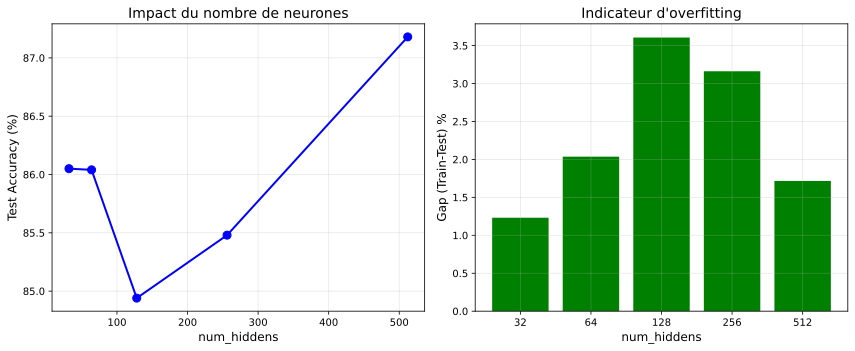

✅ Graphique sauvegardé: figures/accuracy_vs_hiddens.png


In [14]:
# Graph 1: Accuracy vs hidding
os.makedirs('figures', exist_ok=True)

test_final = [results[h]['test'][-1] for h in hidden_sizes]

plt.figure(figsize=(12,5))

# Graph a gauche: Accuracy
plt.subplot(1,2,1)
plt.plot(hidden_sizes, test_final, 'o-', linewidth=2, markersize=8, color='blue')
plt.xlabel('num_hiddens', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Impact du nombre de neurones', fontsize=14)
plt.grid(True, alpha=0.3)

# Graph a droite: Gap (indicateur d'overfitting)
plt.subplot(1,2,2)
gaps = [results[h]['train'][-1] - results[h]['test'][-1] for h in hidden_sizes]
colors = ['green' if g < 5 else 'orange' if g < 10 else 'red' for g in gaps]
plt.bar([str(h) for h in hidden_sizes], gaps, color=colors)
plt.xlabel('num_hiddens', fontsize=12)
plt.ylabel('Gap (Train-Test) %', fontsize=12)
plt.title("Indicateur d'overfitting", fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/accuracy_vs_hiddens.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé: figures/accuracy_vs_hiddens.png")

EXPÉRIENCE 2: Variation du learning rate

Entraînement avec lr = 0.001...
Epoch  1: Train=25.16%, Test=40.85%
Epoch  2: Train=48.52%, Test=54.50%
Epoch  3: Train=58.90%, Test=63.15%
Epoch  4: Train=65.50%, Test=67.77%
Epoch  5: Train=68.57%, Test=69.37%
Epoch  6: Train=70.27%, Test=70.48%
Epoch  7: Train=71.39%, Test=71.19%
Epoch  8: Train=72.12%, Test=71.98%
Epoch  9: Train=72.75%, Test=72.56%
Epoch 10: Train=73.25%, Test=72.98%
  → Test accuracy: 72.98%

Entraînement avec lr = 0.01...
Epoch  1: Train=64.27%, Test=73.11%
Epoch  2: Train=75.64%, Test=76.25%
Epoch  3: Train=78.16%, Test=78.09%
Epoch  4: Train=79.79%, Test=79.15%
Epoch  5: Train=81.00%, Test=80.02%
Epoch  6: Train=81.77%, Test=80.60%
Epoch  7: Train=82.30%, Test=81.25%
Epoch  8: Train=82.81%, Test=81.64%
Epoch  9: Train=83.10%, Test=81.99%
Epoch 10: Train=83.48%, Test=82.24%
  → Test accuracy: 82.24%

Entraînement avec lr = 0.1...
Epoch  1: Train=75.84%, Test=80.49%
Epoch  2: Train=82.89%, Test=83.15%
Epoch  3: Train=84.

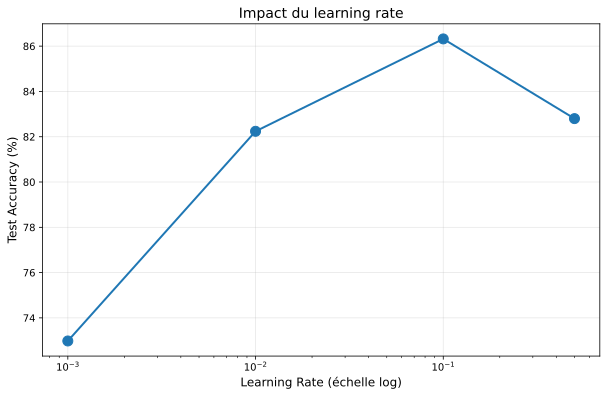


✅ Meilleur learning rate: 0.1 avec 86.32%


In [15]:
# Graph 2 : Impact of learning rate
learning_rates = [0.001, 0.01, 0.1, 0.5]
lr_results = []

print("="*60)
print("EXPÉRIENCE 2: Variation du learning rate")
print("="*60)

for lr in learning_rates:
    print(f"\nEntraînement avec lr = {lr}...")
    model = MLPConcise(num_outputs=10, num_hiddens=128)
    _, test_accs = train_model(model, train_loader, test_loader, epochs=10, lr=lr)
    lr_results.append(test_accs[-1])
    print(f"  → Test accuracy: {test_accs[-1]:.2f}%")

plt.figure(figsize=(10,6))
plt.semilogx(learning_rates, lr_results, 'o-', linewidth=2, markersize=10)
plt.xlabel('Learning Rate (échelle log)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Impact du learning rate', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('figures/accuracy_vs_lr.png', dpi=150)
plt.show()

best_lr = learning_rates[np.argmax(lr_results)]
print(f"\n✅ Meilleur learning rate: {best_lr} avec {max(lr_results):.2f}%")

Epoch  1: Train=76.54%, Test=77.85%
Epoch  2: Train=83.11%, Test=82.72%
Epoch  3: Train=84.92%, Test=83.25%
Epoch  4: Train=85.80%, Test=84.88%
Epoch  5: Train=86.62%, Test=84.16%
Epoch  6: Train=87.08%, Test=85.08%
Epoch  7: Train=87.47%, Test=85.83%
Epoch  8: Train=87.95%, Test=86.02%
Epoch  9: Train=88.18%, Test=86.12%
Epoch 10: Train=88.61%, Test=86.28%


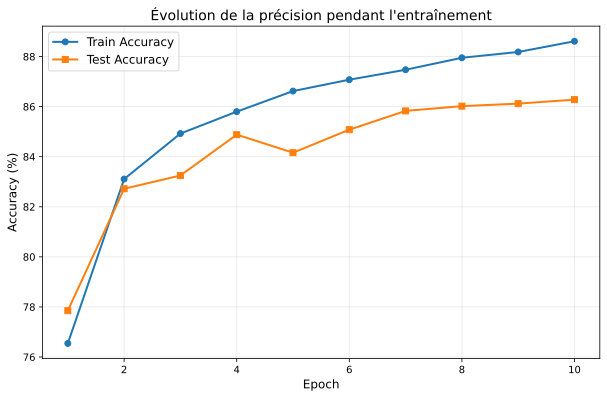

✅ Graphique sauvegardé: figures/accuracy_vs_epochs.png


In [18]:
#  Graph 3 : Train and Test Accuracy par epoch (pour voir overfitting)
model_optimal = MLPConcise(num_outputs=10, num_hiddens=256)
train_hist, test_hist = train_model(model_optimal, train_loader, test_loader, epochs=10, lr=0.1)

plt.figure(figsize=(10,6))
plt.plot(range(1, 11), train_hist, 'o-', label='Train Accuracy', linewidth=2)
plt.plot(range(1, 11), test_hist, 's-', label='Test Accuracy', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Évolution de la précision pendant l\'entraînement', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('figures/accuracy_vs_epochs.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé: figures/accuracy_vs_epochs.png")

ANALYSE UNDERFITTING vs OVERFITTING

1. UNDERFITTING (h=16):
Epoch  1: Train=74.17%, Test=80.34%
Epoch  2: Train=81.73%, Test=78.58%
Epoch  3: Train=83.35%, Test=81.36%
Epoch  4: Train=84.09%, Test=80.28%
Epoch  5: Train=84.97%, Test=84.01%
Epoch  6: Train=85.30%, Test=80.30%
Epoch  7: Train=85.65%, Test=77.79%
Epoch  8: Train=86.03%, Test=82.79%
Epoch  9: Train=86.32%, Test=83.40%
Epoch 10: Train=86.49%, Test=84.16%

2. OVERFITTING (h=512):
Epoch  1: Train=77.02%, Test=81.55%
Epoch  2: Train=83.42%, Test=80.73%
Epoch  3: Train=84.93%, Test=83.47%
Epoch  4: Train=86.08%, Test=80.31%
Epoch  5: Train=86.89%, Test=85.73%
Epoch  6: Train=87.32%, Test=84.91%
Epoch  7: Train=87.82%, Test=85.26%
Epoch  8: Train=88.20%, Test=85.83%
Epoch  9: Train=88.59%, Test=84.18%
Epoch 10: Train=88.99%, Test=86.76%


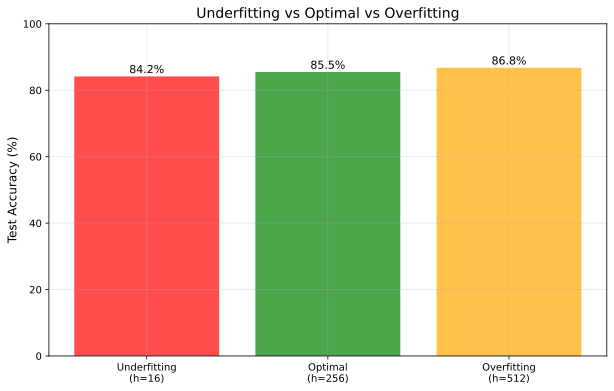

✅ Graphique sauvegardé: figures/under_overfitting.png

DIAGNOSTIC:

✅ OPTIMAL: h=256 → Test=85.5%


In [20]:
# Graph 4: Underfitting vs Optimal vs Overfitting
print("="*60)
print("ANALYSE UNDERFITTING vs OVERFITTING")
print("="*60)

print("\n1. UNDERFITTING (h=16):")
model_small = MLPConcise(num_outputs=10, num_hiddens=16)
train_small, test_small = train_model(model_small, train_loader, test_loader, epochs=10, lr=0.1)


print("\n2. OVERFITTING (h=512):")
model_large = MLPConcise(num_outputs=10, num_hiddens=512)
train_large, test_large = train_model(model_large, train_loader, test_loader, epochs=10, lr=0.1)

plt.figure(figsize=(10,6))
categories = ['Underfitting\n(h=16)', 'Optimal\n(h=256)', 'Overfitting\n(h=512)']
train_values = [test_small[-1], results[256]['test'][-1], test_large[-1]]

colors = ['red', 'green', 'orange']
bars = plt.bar(categories, train_values, color=colors, alpha=0.7)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Underfitting vs Optimal vs Overfitting', fontsize=14)
plt.ylim(0, 100)


for bar, val in zip(bars, train_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=11)

plt.grid(True, alpha=0.3)
plt.savefig('figures/under_overfitting.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé: figures/under_overfitting.png")


print("\n" + "="*60)
print("DIAGNOSTIC:")
print("="*60)
if test_small[-1] < 70:
    print(f"⚠️ UNDERFITTING: h=16 → Test={test_small[-1]:.1f}% (modèle trop simple)")
if test_large[-1] < results[256]['test'][-1]:
    print(f"⚠️ OVERFITTING: h=512 → Test={test_large[-1]:.1f}% (modèle trop complexe)")
print(f"\n✅ OPTIMAL: h=256 → Test={results[256]['test'][-1]:.1f}%")

In [21]:
# Téléchargement des figures
import zipfile
from google.colab import files

with zipfile.ZipFile('figures.zip', 'w') as zipf:
    for root, dirs, files_list in os.walk('figures'):
        for file in files_list:
            zipf.write(os.path.join(root, file))


files.download('figures.zip')
print("✅ Figures téléchargées!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Figures téléchargées!
